In [1]:
from qeep import plot

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax.numpy as jnp


In [2]:
configuration = '../../configs/abacus/config_desi_asymm.yaml'
configuration_full_weights = '../../configs/abacus/config_desi_asymm_full_var.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

In [3]:
name = config["name"]

path = f"../../results/{name}/"

norm = np.load(path+f"analysis_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_theory_variance_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_theory_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_theory_shot_trispectrum_AB.npy", allow_pickle = True).item()

### Responses

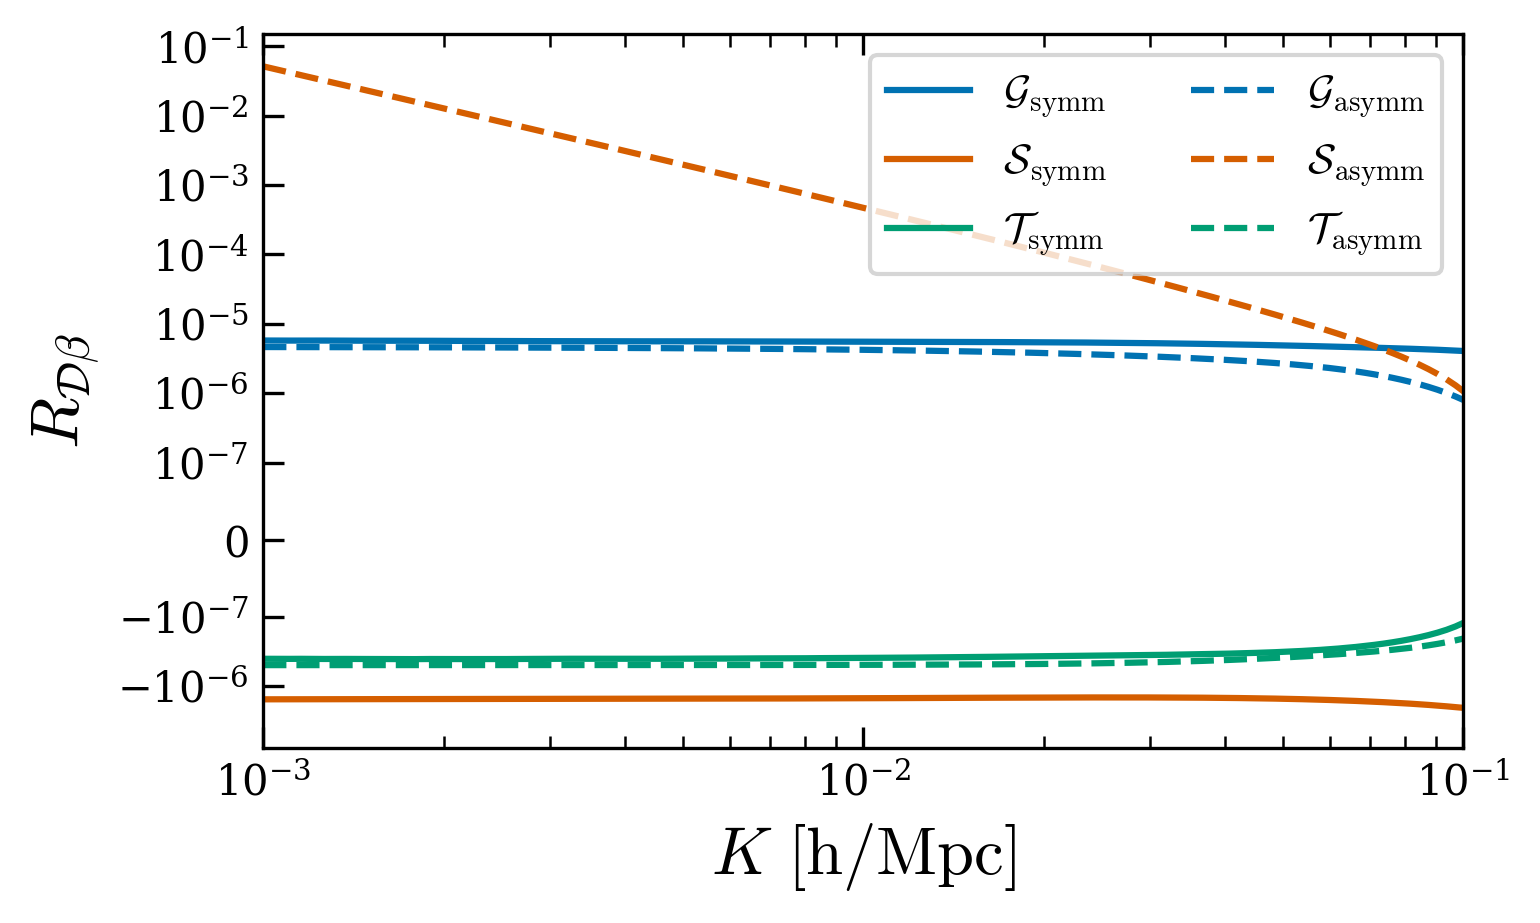

In [4]:
mainkey = "n"
kother = "sa" 

# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]

normalized = False

if normalized:
    N = norm[(mainkey, mainkey)]**-1.
else:
    N = 1
    
for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i%3]
    R = norm[(mainkey, k)]
    ax.loglog(Ks, N*(R), label = plot.names[k], color = color_, ls = "-" if i < 3 else "--")

R = norm[(kother, kother)]
#ax.loglog(Ks, N*(R), label = labels[-2]+labels[-2], color = "black", ls = "-", lw = 1, alpha = 0.5)

    
ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)

if normalized:
    ax.set_ylabel(r'$N_{\mathcal{D}\mathcal{D}}R_{{\mathcal{D}\beta}}$', fontsize=16)
else:
    ax.set_ylabel(r'$R_{{\mathcal{D}\beta}}$', fontsize=16)


ax.legend(ncol = 2, loc = "upper right")
ax.set_xlim(1e-3, 1e-1)
if normalized:
    ax.set_ylim(1e-5, 3)
else:
    #ax.set_ylim(-1e-7, 1e-7)
    pass

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/responses.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

### Biases

In [5]:
from qeep import biases

def get_tot_bias(key, norm, Cg, keys = ["g", "s", "t", "ga", "sa", "ta"]):
    N = np.array(norm[(key, key)]**-1.)
    N[N>1e10] = 0
    N = jnp.array(N)
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = norm[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    partials = N * jax_out_normalization_AB * Cg[:, jnp.newaxis]
    return jnp.nan_to_num(partials)

biases_dict = config["bias"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3 #biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 1, 1, 1, 1, 1, 1
#bGXA, bGXB = bGX(b1A), bGX(b1B)
#bSXA, bSXB = bSX(b1A), bSX(b1B)
#bTXA, bTXB = bTX(b1A), bTX(b1B)
print(b1A, b1B)

1.6 1.2


In [6]:
mainkey = "n"
kother = "sa" 

#jnp.array([Cg_g, Cg_s, Cg_t, Cg_ga, Cg_sa, Cg_ta])
Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = 1., only_asymm_shift = 0.)

Cg_10 = biases.get_Cg_biases(e*10, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = 1., only_asymm_shift = 0.)


estimator_biases = get_tot_bias(mainkey, norm, Cg)
estimator_biases_10 = get_tot_bias(mainkey, norm, Cg_10)

IndexError: list index out of range

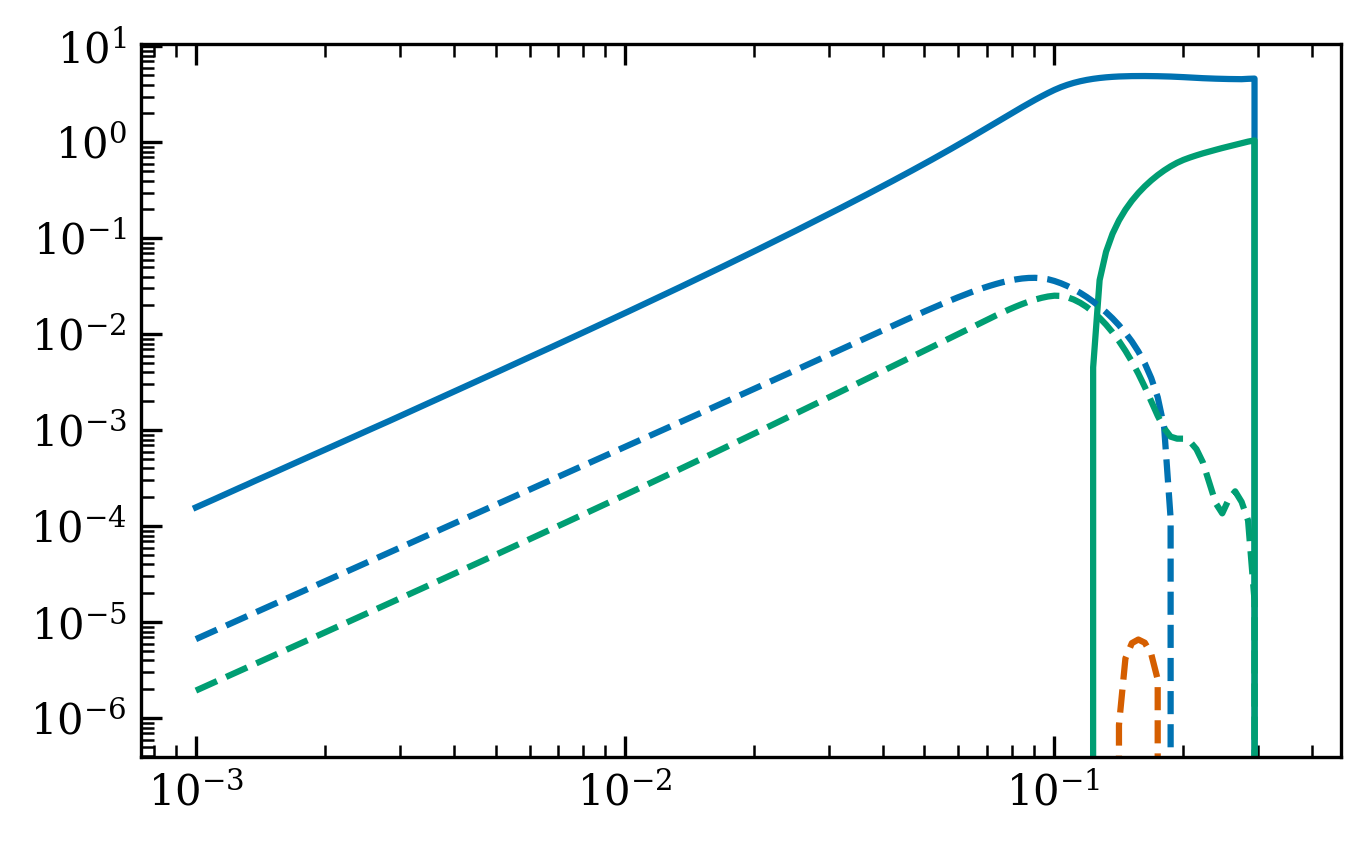

In [7]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]

for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i%3]
    ax.loglog(Ks, estimator_biases[i], label = plot.names[k], color = color_, ls = "-" if i < 3 else "--")


ax.loglog(Ks, estimator_biases_10[keys.index(kother)], label = plot.names[kother]+" ($\\epsilon \\times 10$)", color = plot.COLORBLIND_PALETTE[7], ls = "--")

ax.loglog(Ks, estimator_biases.sum(axis = 0), label = "Sum", color = "black")
    
ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)

ax.set_ylabel(r'$B_{{\mathcal{D}\beta}}$', fontsize=16)

ax.legend(ncol = 2, loc = "upper right")
ax.set_xlim(1e-3, 1e-1)

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/bias.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Compare variance

In [ ]:
def get(mainkey):
    key = (mainkey, mainkey)
    N = norm[key]**-1.
    V = var[key]*N**2
    return N, V

# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]

# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

ax.plot(Ks, plinf(Ks), color = "yellow", lw = 3)

keys = ["g", "s", "t"]#, "t", "ga", "sa", "ta", "n"]

for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i]
    N, V = get(k)
    ax.loglog(Ks, V, label = plot.names[k], color = color_)
    ax.loglog(Ks, N, color = color_, ls = "--")
    #print(V/N)

ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)

ax.set_ylabel(r'$V_{{\alpha\alpha}}$', fontsize=16)

ax.legend(ncol = 2, loc = "lower right", fontsize = 8)
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(ymax = 1e8)

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/variance.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Comparing with variance of optimal weights

In [19]:
from qeep import qeresults as qres

with open(configuration_full_weights, 'r') as f:
    config_optimal = yaml.safe_load(f)
QR = qres.QEResults(config_optimal)
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()

QR = qres.QEResults(config)
get_norm = QR.get_get_norm()
get_var = QR.get_get_variance()

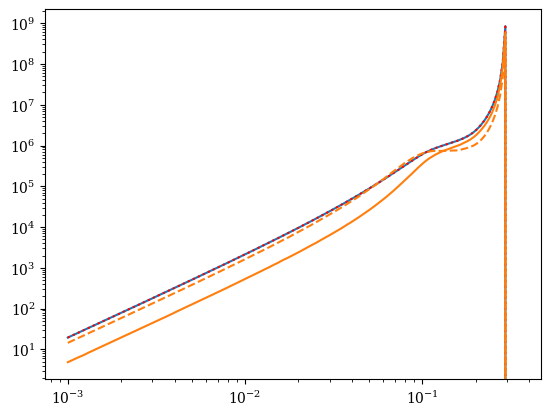

In [34]:
key = "n"

p = plt.loglog(Ks, get_norm(key))
plt.loglog(Ks, get_norm_opt(key), ls = ":", color = "red")

p = plt.loglog(Ks, get_var(key))
plt.loglog(Ks, get_var_opt(key), ls = "--", color = p[0].get_color())



## Check shot bispectrum and trispectrum

In [9]:
mainkey = "n"

mainkey = "sa"
kother = "sa"

key = (mainkey, mainkey)
N = norm[key]**-1.


V = var[key]
T = tris[key]
S = bis[key]

plt.loglog(Ks, (V*N**2))
plt.loglog(Ks, (N), ls = "--")
plt.loglog(Ks, (S*N))

plt.loglog(Ks, abs(T*N**2), lw = 2)

plt.plot(Ks, plinf(Ks), lw = 2, color = "black", ls = "--")

KeyError: ('sa', 'sa')